In [51]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

# Load ORIGINAL dataset
df = pd.read_csv("../data/Road Accident Data.csv")

# Select the columns used by the model
columns = [
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Light_Conditions",
    "Road_Type",
    "Speed_limit",
    "Number_of_Vehicles",
    "Number_of_Casualties",
    "Accident_Severity"
]

ml_df = df[columns].copy()

# Remove missing values
ml_df.dropna(inplace=True)

# Create encoders
encoders = {}

categorical_columns = [
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Light_Conditions",
    "Road_Type"
]

for col in categorical_columns:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col])
    encoders[col] = le

# Save encoders
joblib.dump(encoders, "../models/encoders.pkl")

print("Encoders saved successfully!")
print(encoders.keys())

Encoders saved successfully!
dict_keys(['Weather_Conditions', 'Road_Surface_Conditions', 'Light_Conditions', 'Road_Type'])


In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [53]:
df = pd.read_csv("../data/Road Accident Data.csv")

df.head()

,Accident_Index,Accident Date,Month,Day_of_Week,Year,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,1/1/2021,Jan,Thursday,2021,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,...,1,2,Metropolitan Police,Dry,One way street,30,15:11,Urban,Fine no high winds,Car
1,200901BS70002,1/5/2021,Jan,Monday,2021,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,1/4/2021,Jan,Sunday,2021,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,1/5/2021,Jan,Monday,2021,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10,Urban,Other,Motorcycle over 500cc
4,200901BS70005,1/6/2021,Jan,Tuesday,2021,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25,Urban,Fine no high winds,Car


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Accident_Index              307973 non-null  str    
 1   Accident Date               307973 non-null  str    
 2   Month                       307973 non-null  str    
 3   Day_of_Week                 307973 non-null  str    
 4   Year                        307973 non-null  int64  
 5   Junction_Control            307973 non-null  str    
 6   Junction_Detail             307973 non-null  str    
 7   Accident_Severity           307973 non-null  str    
 8   Latitude                    307973 non-null  float64
 9   Light_Conditions            307973 non-null  str    
 10  Local_Authority_(District)  307973 non-null  str    
 11  Carriageway_Hazards         5424 non-null    str    
 12  Longitude                   307973 non-null  float64
 13  Number_of_Casualties     

In [55]:
df.shape

(307973, 23)

In [56]:
df.describe()

,Year,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000
mean,2021.468934,52.487005,-1.368884,1.356882,1.829063,38.866037
std,0.499035,1.339011,1.356092,0.815857,0.710477,14.032933
min,2021.000000,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,2021.000000,51.485248,-2.247937,1.000000,1.000000,30.000000
50%,2021.000000,52.225943,-1.349258,1.000000,2.000000,30.000000
75%,2022.000000,53.415517,-0.206810,1.000000,2.000000,50.000000
max,2022.000000,60.598055,1.759398,48.000000,32.000000,70.000000


In [57]:
df.isnull().sum()

Accident_Index                     0
Accident Date                      0
Month                              0
Day_of_Week                        0
Year                               0
Junction_Control                   0
Junction_Detail                    0
Accident_Severity                  0
Latitude                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Longitude                          0
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions          317
Road_Type                       1534
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions              6057
Vehicle_Type                       0
dtype: int64

In [58]:
 #Data Cleaning

df_clean = df.copy()

In [59]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Rows:", duplicates)


Duplicate Rows: 1


In [60]:
df_clean.drop_duplicates(inplace=True)

In [61]:
#cheakingmissingvalues
df_clean.isnull().sum().sort_values(ascending=False)

Carriageway_Hazards           302548
Weather_Conditions              6057
Road_Type                       1534
Road_Surface_Conditions          317
Time                              17
Accident Date                      0
Accident_Index                     0
Junction_Detail                    0
Junction_Control                   0
Year                               0
Day_of_Week                        0
Month                              0
Accident_Severity                  0
Light_Conditions                   0
Latitude                           0
Number_of_Vehicles                 0
Number_of_Casualties               0
Longitude                          0
Local_Authority_(District)         0
Speed_limit                        0
Police_Force                       0
Urban_or_Rural_Area                0
Vehicle_Type                       0
dtype: int64

In [62]:
df_clean.drop(columns=["Carriageway_Hazards"], inplace=True)

In [63]:
df_clean.columns

Index(['Accident_Index', 'Accident Date', 'Month', 'Day_of_Week', 'Year',
       'Junction_Control', 'Junction_Detail', 'Accident_Severity', 'Latitude',
       'Light_Conditions', 'Local_Authority_(District)', 'Longitude',
       'Number_of_Casualties', 'Number_of_Vehicles', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Time',
       'Urban_or_Rural_Area', 'Weather_Conditions', 'Vehicle_Type'],
      dtype='str')

In [64]:
df_clean["Weather_Conditions"].fillna(
    df_clean["Weather_Conditions"].mode()[0],
    inplace=True
)

df_clean["Road_Type"].fillna(
    df_clean["Road_Type"].mode()[0],
    inplace=True
)

df_clean["Road_Surface_Conditions"].fillna(
    df_clean["Road_Surface_Conditions"].mode()[0],
    inplace=True
)

df_clean["Time"].fillna(
    df_clean["Time"].mode()[0],
    inplace=True
)

C:\Users\Dipika\AppData\Local\Temp\ipykernel_29448\4053420908.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean["Weather_Conditions"].fillna(
C:\Users\Dipika\AppData\Local\Temp\ipykernel_29448\4053420908.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using a

0         15:11
1         10:59
2         14:19
3          8:10
4         17:25
          ...  
307968     7:00
307969     3:00
307970     9:38
307971    18:25
307972    15:45
Name: Time, Length: 307972, dtype: str

In [65]:
df_clean.isnull().sum()

Accident_Index                   0
Accident Date                    0
Month                            0
Day_of_Week                      0
Year                             0
Junction_Control                 0
Junction_Detail                  0
Accident_Severity                0
Latitude                         0
Light_Conditions                 0
Local_Authority_(District)       0
Longitude                        0
Number_of_Casualties             0
Number_of_Vehicles               0
Police_Force                     0
Road_Surface_Conditions        317
Road_Type                     1534
Speed_limit                      0
Time                            17
Urban_or_Rural_Area              0
Weather_Conditions            6057
Vehicle_Type                     0
dtype: int64

In [66]:
df_clean.to_csv("../data/cleaned_accident_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [67]:
# Exploratory Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

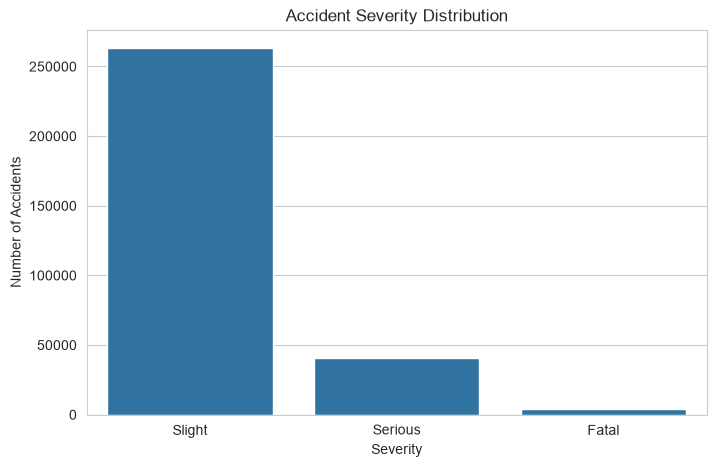

In [68]:
#Accident Severity Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Accident_Severity",
    order=df_clean["Accident_Severity"].value_counts().index
)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.show()

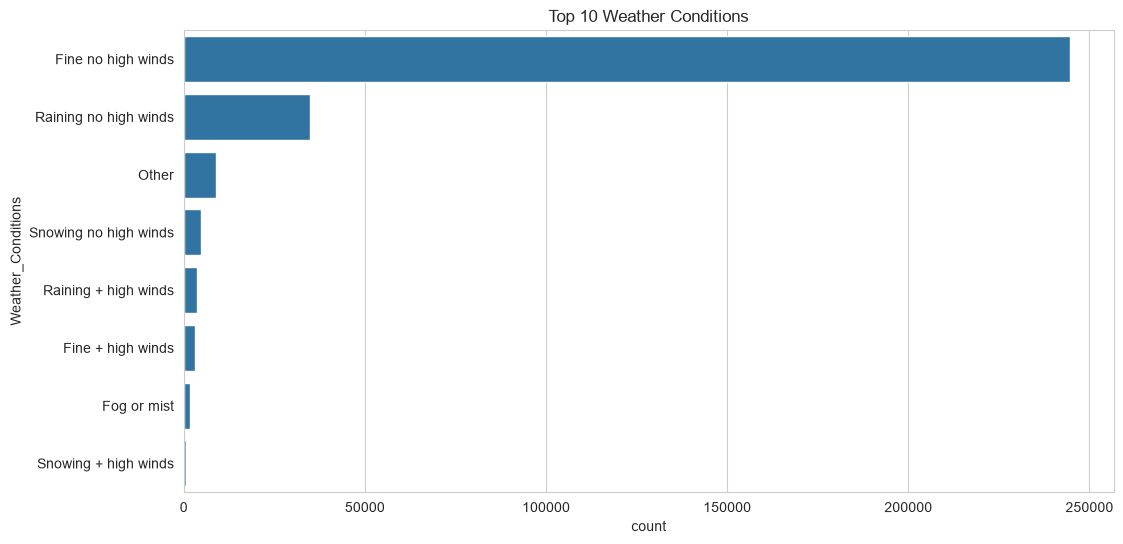

In [69]:
#Weather Conditions
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_clean,
    y="Weather_Conditions",
    order=df_clean["Weather_Conditions"].value_counts().head(10).index
)

plt.title("Top 10 Weather Conditions")
plt.show()

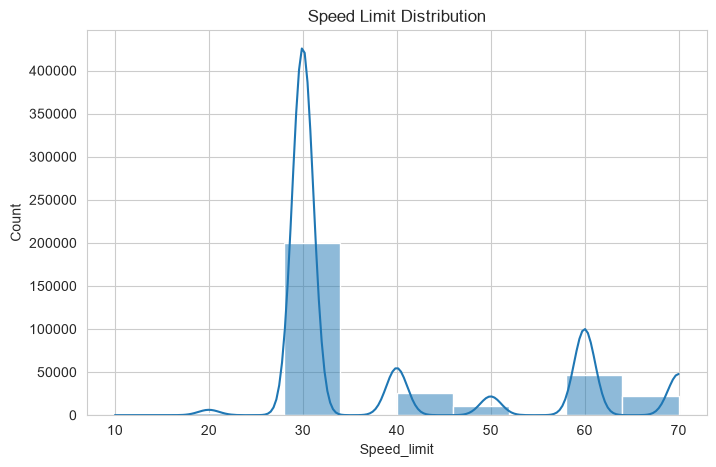

In [70]:
#Speed Limit Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Speed_limit"],
    bins=10,
    kde=True
)

plt.title("Speed Limit Distribution")
plt.show()

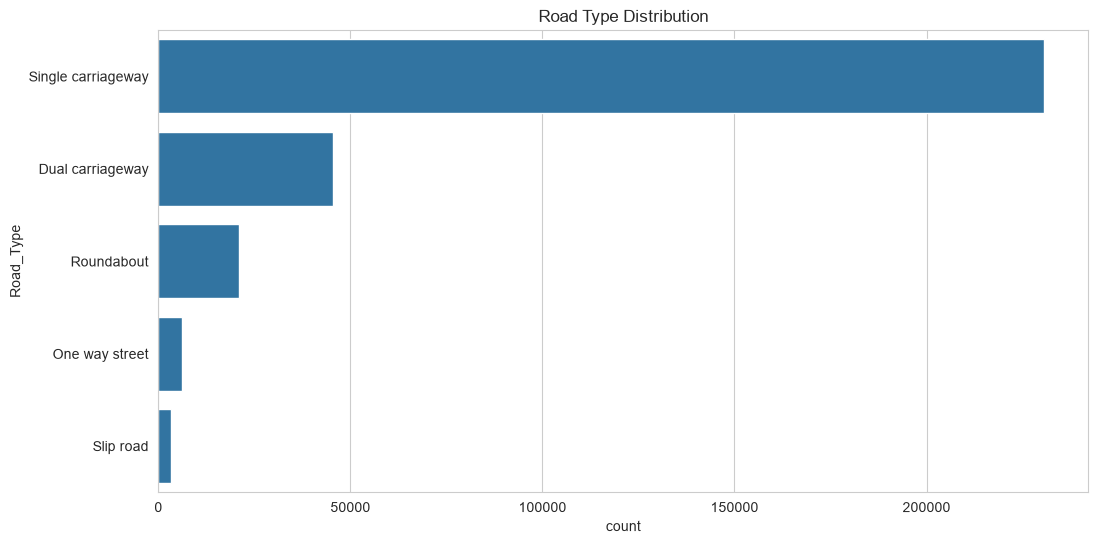

In [71]:
#Road Type
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_clean,
    y="Road_Type",
    order=df_clean["Road_Type"].value_counts().index
)

plt.title("Road Type Distribution")
plt.show()

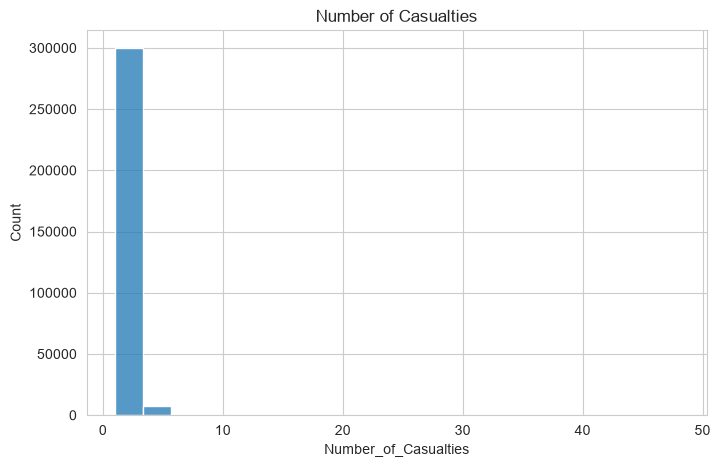

In [72]:
#Number of Casualties
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Number_of_Casualties"],
    bins=20
)

plt.title("Number of Casualties")
plt.show()

In [73]:
#Correlation Heatmap
#First create a dataframe containing only numerical columns.

numeric_df = df_clean.select_dtypes(include=["int64","float64"])

numeric_df.head()

,Year,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
0,2021,51.512273,-0.201349,1,2,30
1,2021,51.514399,-0.199248,11,2,30
2,2021,51.486668,-0.179599,1,2,30
3,2021,51.507804,-0.203110,1,2,30
4,2021,51.482076,-0.173445,1,2,30


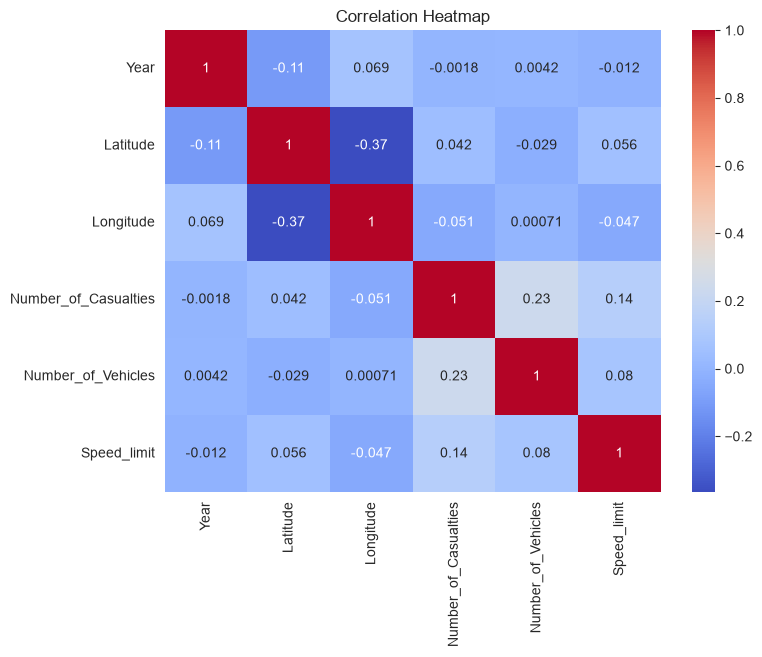

In [74]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [75]:
# Machine Learning Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [76]:
ml_df = df_clean.copy()

In [77]:
columns = [
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Light_Conditions",
    "Road_Type",
    "Speed_limit",
    "Number_of_Vehicles",
    "Number_of_Casualties",
    "Accident_Severity"
]

ml_df = ml_df[columns]

In [78]:

ml_df.dropna(inplace=True)

In [79]:

from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

for col in ml_df.columns:
    if ml_df[col].dtype == "object":
        le = LabelEncoder()
        ml_df[col] = le.fit_transform(ml_df[col].astype(str))
        encoders[col] = le

joblib.dump(encoders, "../models/encoders.pkl")

['../models/encoders.pkl']

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib

# Load data
df = pd.read_csv("../data/Road Accident Data.csv")

# Columns
categorical_columns = [
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Light_Conditions",
    "Road_Type"
]

numerical_columns = [
    "Speed_limit",
    "Number_of_Vehicles",
    "Number_of_Casualties"
]

target = "Accident_Severity"

# Remove missing values
df = df[categorical_columns + numerical_columns + [target]].dropna()

# Encode categorical input columns
encoders = {}

for col in categorical_columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col].astype(str))
    encoders[col] = encoder

# Encode target
target_encoder = LabelEncoder()
df[target] = target_encoder.fit_transform(df[target].astype(str))

# Create X and y
X = df[categorical_columns + numerical_columns]
y = df[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Report
print(classification_report(y_test, y_pred))

# Save model
joblib.dump(model, "../models/accident_model.pkl")

# Save encoders
joblib.dump(encoders, "../models/encoders.pkl")

print("Model and encoders saved successfully!")

Accuracy: 0.8517544881287124
              precision    recall  f1-score   support

           0       0.12      0.00      0.01       779
           1       0.26      0.01      0.02      8017
           2       0.85      1.00      0.92     51307

    accuracy                           0.85     60103
   macro avg       0.41      0.34      0.31     60103
weighted avg       0.77      0.85      0.79     60103

Model and encoders saved successfully!


In [81]:

X = ml_df.drop(columns=["Accident_Severity"])

y = ml_df["Accident_Severity"]

In [82]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [83]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Fine no high winds'

In [ ]:
print(ml_df.dtypes)

print(X.dtypes)

print(y.head())

print(type(y))

Weather_Conditions           str
Road_Surface_Conditions      str
Light_Conditions             str
Road_Type                    str
Speed_limit                int64
Number_of_Vehicles         int64
Number_of_Casualties       int64
Accident_Severity            str
dtype: object
Weather_Conditions           str
Road_Surface_Conditions      str
Light_Conditions             str
Road_Type                    str
Speed_limit                int64
Number_of_Vehicles         int64
Number_of_Casualties       int64
dtype: object
0    Serious
1    Serious
2     Slight
3    Serious
4    Serious
Name: Accident_Severity, dtype: str
<class 'pandas.Series'>


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
categorical_cols = ml_df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Weather_Conditions', 'Road_Surface_Conditions', 'Light_Conditions',
       'Road_Type', 'Accident_Severity'],
      dtype='str')


C:\Users\Dipika\AppData\Local\Temp\ipykernel_29448\2926425973.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = ml_df.select_dtypes(include=['object']).columns


In [ ]:
for col in categorical_cols:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

In [ ]:
encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    ml_df[col] = encoder.fit_transform(ml_df[col].astype(str))
    encoders[col] = encoder

In [ ]:
target_encoder = LabelEncoder()

ml_df["Accident_Severity"] = target_encoder.fit_transform(
    ml_df["Accident_Severity"].astype(str)
)

In [ ]:
print(ml_df.dtypes)

Weather_Conditions         int64
Road_Surface_Conditions    int64
Light_Conditions           int64
Road_Type                  int64
Speed_limit                int64
Number_of_Vehicles         int64
Number_of_Casualties       int64
Accident_Severity          int64
dtype: object


In [ ]:
X = ml_df.drop("Accident_Severity", axis=1)
y = ml_df["Accident_Severity"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8516712976057768
              precision    recall  f1-score   support

           0       0.11      0.00      0.00       794
           1       0.26      0.01      0.02      7998
           2       0.85      1.00      0.92     51311

    accuracy                           0.85     60103
   macro avg       0.41      0.34      0.31     60103
weighted avg       0.77      0.85      0.79     60103



In [ ]:
joblib.dump(model, "../models/accident_model.pkl")
joblib.dump(encoders, "../models/encoders.pkl")

print("Model and encoders saved successfully!")
print(encoders.keys())

Model and encoders saved successfully!
dict_keys(['Weather_Conditions', 'Road_Surface_Conditions', 'Light_Conditions', 'Road_Type', 'Accident_Severity'])


In [ ]:
predictions = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8516712976057768


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.11      0.00      0.00       794
           1       0.26      0.01      0.02      7998
           2       0.85      1.00      0.92     51311

    accuracy                           0.85     60103
   macro avg       0.41      0.34      0.31     60103
weighted avg       0.77      0.85      0.79     60103



In [ ]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import joblib

joblib.dump(model, "../models/accident_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                   Feature  Importance
5       Number_of_Vehicles    0.267964
6     Number_of_Casualties    0.178452
4              Speed_limit    0.162402
0       Weather_Conditions    0.120370
2         Light_Conditions    0.096365
1  Road_Surface_Conditions    0.092617
3                Road_Type    0.081829


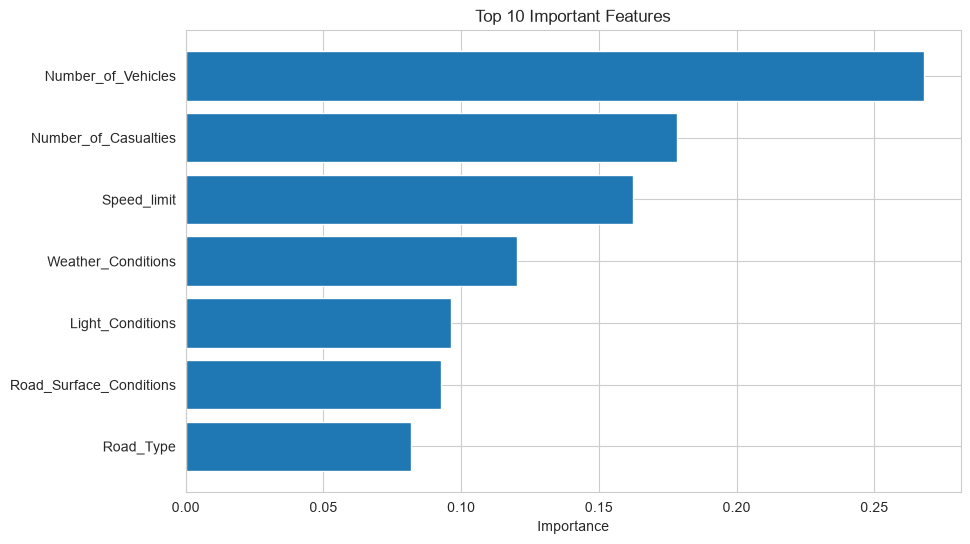

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.xlabel("Importance")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

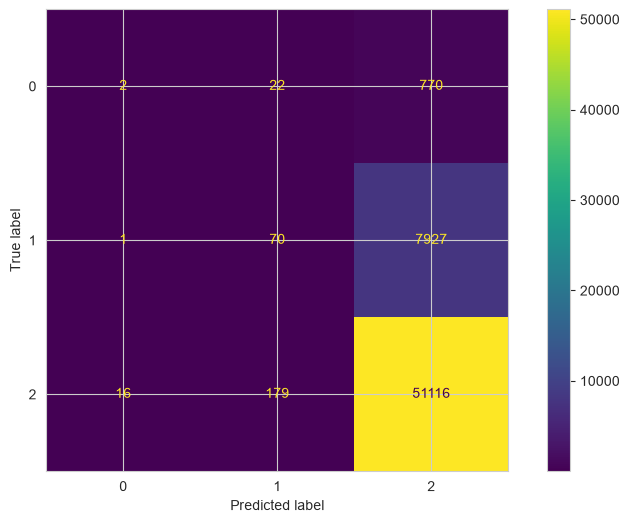

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8516712976057768


In [ ]:
print(type(df_clean))

<class 'pandas.DataFrame'>


In [ ]:
print(type(ml_df))
print(ml_df.head())

<class 'pandas.DataFrame'>
   Weather_Conditions  Road_Surface_Conditions  Light_Conditions  Road_Type  \
0                   1                        0                 4          1   
1                   1                        4                 4          3   
2                   1                        0                 4          3   
3                   3                        2                 4          3   
4                   1                        0                 1          3   

   Speed_limit  Number_of_Vehicles  Number_of_Casualties  Accident_Severity  
0           30                   2                     1                  1  
1           30                   2                    11                  1  
2           30                   2                     1                  2  
3           30                   2                     1                  1  
4           30                   2                     1                  1  


In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

for col in ml_df.columns:
    if ml_df[col].dtype == "object":
        le = LabelEncoder()
        ml_df[col] = le.fit_transform(ml_df[col])
        encoders[col] = le

joblib.dump(encoders, "../models/encoders.pkl")

print("Encoders saved successfully!")

Encoders saved successfully!
